# Reading DEM

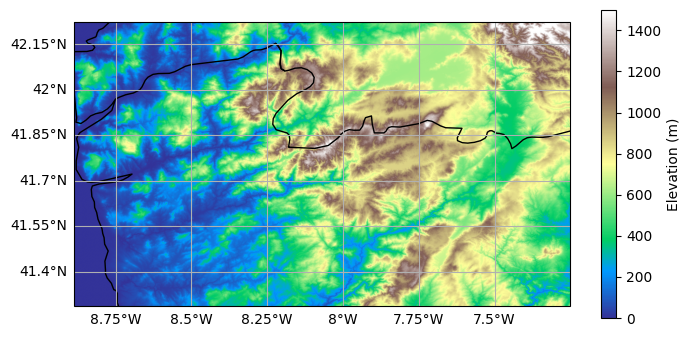

In [1]:
from pysheds.grid import Grid
from matplotlib.colors import LogNorm
import numpy as np,matplotlib.pyplot as plt,cartopy.crs as ccrs,cartopy.feature as cfeature
if not hasattr(np,'in1d'):
    np.in1d=np.isin
fn='output_cop30.tif'
grid=Grid.from_raster(fn,nodata=0)
dem=grid.read_raster(fn,nodata=0)
fig=plt.figure(figsize=(8,4))
ax=plt.axes(projection=ccrs.PlateCarree())
plt.imshow(dem,extent=grid.extent,
           cmap='terrain',
           vmin=0,
           vmax=1500)
plt.colorbar(label='Elevation (m)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=['bottom','left'])

# Computing Flow Directions

In [2]:
pit_filled_dem=grid.fill_pits(dem)
flooded_dem=grid.fill_depressions(pit_filled_dem)
conditioned_dem=grid.resolve_flats(flooded_dem)
flowdir=grid.flowdir(conditioned_dem)
np.unique(flowdir)

Raster([ -2,  -1,   0,   1,   2,   4,   8,  16,  32,  64, 128])

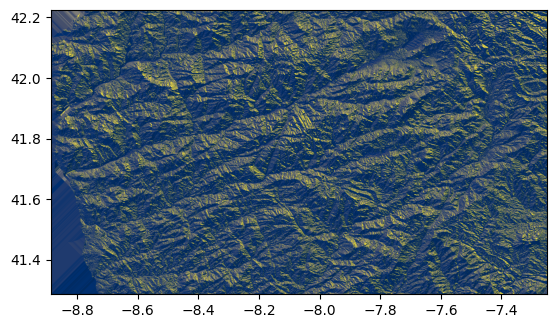

In [3]:
plt.imshow(flowdir,extent=grid.extent,cmap='cividis')

# Computing Catchment Areas

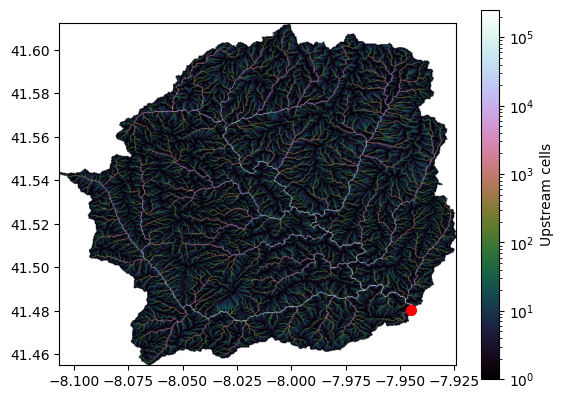

In [4]:
acc=grid.accumulation(flowdir)
x,y=-7.954,41.47
x_snap,y_snap=grid.snap_to_mask(acc>5000,(x,y))
catch=grid.catchment(x=x_snap,
                     y=y_snap,
                     fdir=flowdir,
                     xytype='coordinate')
grid.clip_to(catch)
clipped_catch=grid.view(catch)
clipped_accumulated_flow=grid.accumulation(flowdir)
fig,ax=plt.subplots()
im=ax.imshow(np.where(clipped_catch,clipped_accumulated_flow,np.nan),extent=grid.extent,cmap='cubehelix',norm=LogNorm(1,clipped_accumulated_flow.max()),interpolation='bilinear')
plt.colorbar(im,ax=ax,label='Upstream cells')
plt.scatter([x_snap],[y_snap],c='r',s=50)